<a href="https://ai4life-mdc24.grand-challenge.org/ai4life-mdc24/">
    <img src="https://rumc-gcorg-p-public.s3.amazonaws.com/b/756/denoising.x10.jpeg" height="200" />
</a>

# JUMP dataset

In [2]:
# Imports necessary to execute the code


import os
# os.chdir("D:/Homework/project/")  
# print(os.getcwd())
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pooch
import tifffile
from careamics import CAREamist
from careamics.config import create_n2v_configuration
import torch

# use n2v2
use_n2v2 = True

# folder in which to save all the data
root = Path("jump")
algo = "n2v2" if use_n2v2 else "n2v"
# print(root)

## Import the dataset

In [9]:
# download the data using pooch
# data_root = root / "data"
# dataset_url = "https://zenodo.org/records/10912386/files/noisy.tiff"

# file = pooch.retrieve(
#     url=dataset_url,
#     known_hash="394541cd10b5f10cc929e8083e42f757e47eb0a318cf78448a9e4622179c3069",
#     path=data_root,
# )

## Visualize data

Image shape: (517, 4, 540, 540)


Text(0.5, 1.0, 'Channel 4')

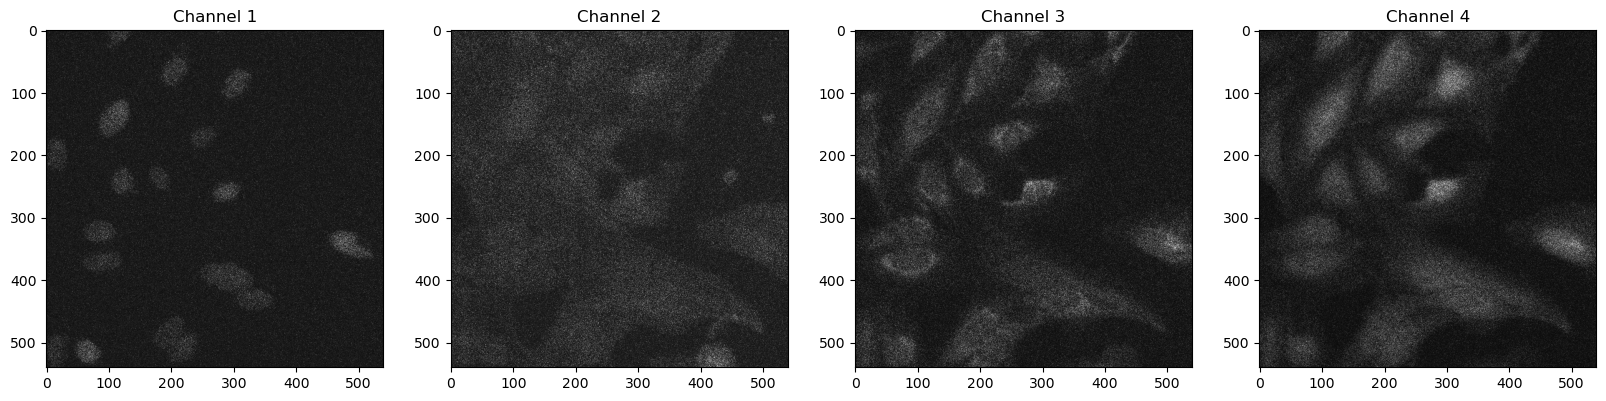

In [3]:
# load training and validation image and show them side by side
train_image = tifffile.imread(r'D:\Homework\project\jump\data\22125685f24e39a69900bc5be41548aa-noisy.tiff')
print(f"Image shape: {train_image.shape}")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(train_image[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(train_image[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(train_image[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(train_image[0][3], cmap="gray")
ax[3].set_title("Channel 4")

## GT Visualize

Image shape: (517, 4, 540, 540)


Text(0.5, 1.0, 'Channel 4')

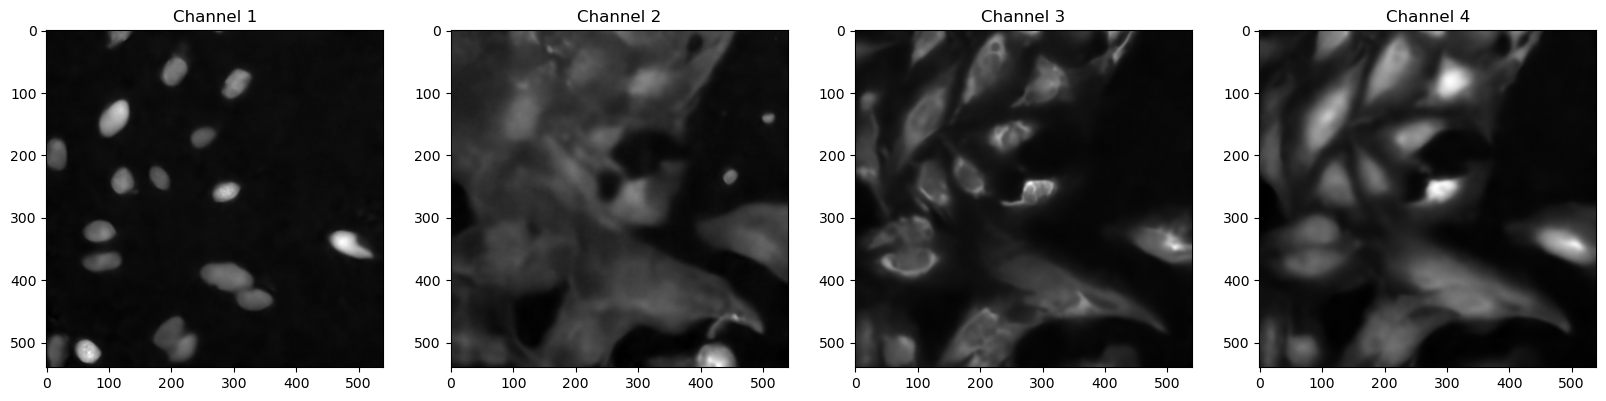

In [4]:
gt_image = tifffile.imread(r'D:\Homework\project\jump\gt\jump2.tif')
print(f"Image shape: {gt_image.shape}")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(gt_image[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(gt_image[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(gt_image[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(gt_image[0][3], cmap="gray")
ax[3].set_title("Channel 4")

## Train with CAREamics

### Create configuration


In [11]:
# create configuration
algo = "n2v2" if use_n2v2 else "n2v"

config = create_n2v_configuration(
    experiment_name="jump_" + algo,
    data_type="array",
    axes="SCYX",
    patch_size=(64, 64),
    batch_size=32,
    num_epochs=15,
    n_channels=4,
    use_n2v2=use_n2v2,
)

print(config)

{'algorithm_config': {'algorithm': 'n2v',
                      'loss': 'n2v',
                      'lr_scheduler': {'name': 'ReduceLROnPlateau',
                                       'parameters': {}},
                      'model': {'architecture': 'UNet',
                                'conv_dims': 2,
                                'depth': 2,
                                'final_activation': 'None',
                                'in_channels': 4,
                                'independent_channels': True,
                                'n2v2': True,
                                'num_channels_init': 32,
                                'num_classes': 4},
                      'optimizer': {'name': 'Adam',
                                    'parameters': {'lr': 0.0001}}},
 'data_config': {'axes': 'SCYX',
                 'batch_size': 32,
                 'data_type': 'array',
                 'patch_size': [64, 64],
                 'train_dataloader_params': {'shuffle

### Train

In [12]:
# instantiate a CAREamist
careamist = CAREamist(
    source=config,
    work_dir=root / algo,
)

# train
careamist.train(
    train_source=train_image,
    val_percentage=0.0,
    val_minimum_split=10,  # use 10 patches as validation
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Computed dataset mean: [0.19990648 0.46144676 0.6830192  0.94634783], std: [0.611      0.80968654 1.0823073  1.4865952 ]
D:\anaconda\envs\hw\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory D:\Homework\project\jump\n2v2\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | UNet | 2.0 M  | train
---------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
8.147     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## Load Checkpoint

In [5]:
careamist = CAREamist(
    # source=config,
    source= r'D:\Homework\project\jump\n2v2\checkpoints\jump_n2v2.ckpt',
    # work_dir=root / algo,
)

No working directory provided. Using current working directory: D:\Homework\project.
D:\anaconda\envs\hw\Lib\site-packages\careamics\model_io\model_io_utils.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues rel

## Predict 

In [6]:
prediction = careamist.predict(
    source=train_image,
    tile_size=(256, 256),
    tile_overlap=(48, 48),
    batch_size=1,
)

You are using a CUDA device ('NVIDIA GeForce RTX 4070 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
D:\anaconda\envs\hw\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

### Save predictions

In [7]:
pred_folder = root / ("results_" + algo)
pred_folder.mkdir(exist_ok=True, parents=True)

final_data = np.concatenate(prediction)
tifffile.imwrite(pred_folder / "prediction.tiff", final_data)

### Visualize the prediction

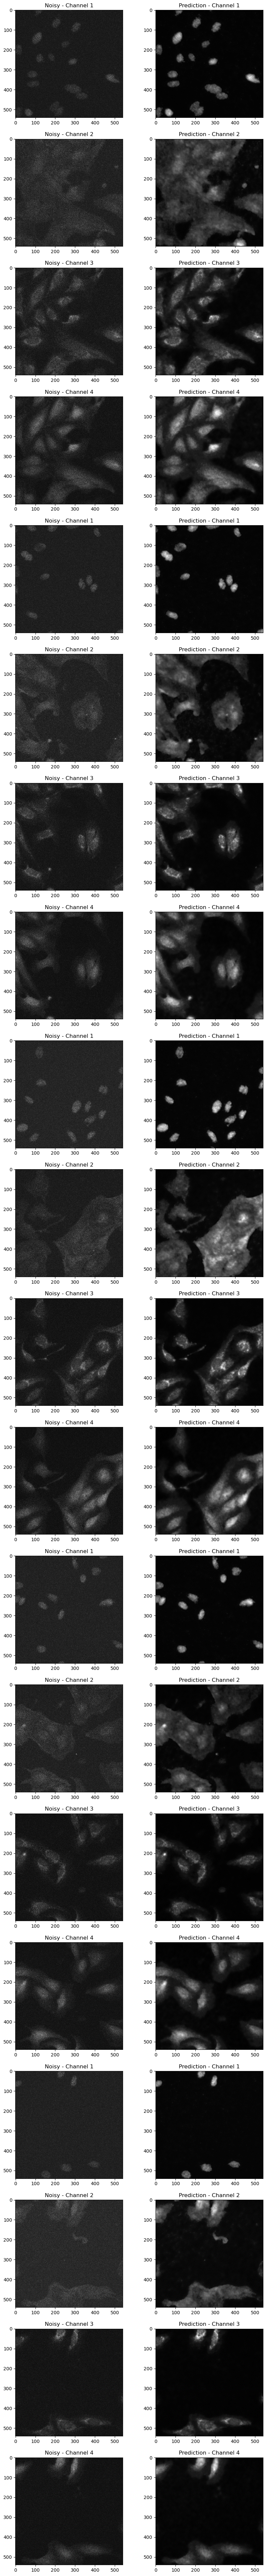

In [8]:
n = 5

fig, ax = plt.subplots(4 * n, 2, figsize=(10, 4 * n * 5))
for i in range(n):
    row = 4 * i

    # channel 1
    ax[row, 0].imshow(train_image[i, 0], cmap="gray")
    ax[row, 0].set_title("Noisy - Channel 1")
    ax[row, 1].imshow(prediction[i].squeeze()[0], cmap="gray")
    ax[row, 1].set_title("Prediction - Channel 1")

    # channel 2
    ax[row + 1, 0].imshow(train_image[i, 1], cmap="gray")
    ax[row + 1, 0].set_title("Noisy - Channel 2")
    ax[row + 1, 1].imshow(prediction[i].squeeze()[1], cmap="gray")
    ax[row + 1, 1].set_title("Prediction - Channel 2")

    # channel 3
    ax[row + 2, 0].imshow(train_image[i, 2], cmap="gray")
    ax[row + 2, 0].set_title("Noisy - Channel 3")
    ax[row + 2, 1].imshow(prediction[i].squeeze()[2], cmap="gray")
    ax[row + 2, 1].set_title("Prediction - Channel 3")

    # channel 4
    ax[row + 3, 0].imshow(train_image[i, 3], cmap="gray")
    ax[row + 3, 0].set_title("Noisy - Channel 4")
    ax[row + 3, 1].imshow(prediction[i].squeeze()[3], cmap="gray")
    ax[row + 3, 1].set_title("Prediction - Channel 4")

In [9]:
prediction = np.concatenate(prediction, axis=0)
# prediction[i].squeeze()[2]

## Compute metrics

In [ ]:
# train_image[i, 2]

# prediction[i].squeeze()[2]


import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from pytorch_msssim import ms_ssim


def scale_invariant_psnr(gt, pred, data_range=1.0):
    numerator = np.sum(gt * pred)
    denominator = np.sum(pred ** 2)

    if denominator < 1e-12:
        alpha = 0.0
    else:
        alpha = numerator / denominator

    scaled_pred = alpha * pred
    mse = np.mean((gt - scaled_pred) ** 2)

    if mse < 1e-12:
        return 100.0

    sip = 10 * np.log10((data_range ** 2) / mse)
    return sip


def calculate_metrics(train_image, prediction, data_range=22.0):
    psnr_list = []
    sipsnr_list = []
    ssim_list = []
    msssim_list = []

    N, C, H, W = train_image.shape

    for i in range(N):
        for c in range(C):
            gt = train_image[i, c]            # shape: (H, W)
            pred = prediction[i, c]          # shape: (H, W)

            p = peak_signal_noise_ratio(gt, pred, data_range=data_range)
            psnr_list.append(p)

            sp = scale_invariant_psnr(gt, pred, data_range=data_range)
            sipsnr_list.append(sp)

            s = structural_similarity(gt, pred, data_range=data_range)
            ssim_list.append(s)

            gt_ms = np.expand_dims(gt, axis=0)  # shape: (1, H, W)
            gt_ms = torch.tensor(np.expand_dims(gt_ms, axis=0))
            pred_ms = np.expand_dims(pred, axis=0)  # shape: (1, H, W)
            pred_ms = torch.tensor(np.expand_dims(pred_ms, axis=0))
            
            ms = ms_ssim(gt_ms, pred_ms, data_range=data_range)
            msssim_list.append(ms)

    metrics = {
        'PSNR':     np.mean(psnr_list),
        'SIPSNR':   np.mean(sipsnr_list),
        'SSIM':     np.mean(ssim_list),
        'MS-SSIM':  np.mean(msssim_list),
    }
    return metrics


metrics_dict = calculate_metrics(gt_image, prediction, data_range=22.0)
print("PSNR:   ", metrics_dict['PSNR'])
print("SIPSNR: ", metrics_dict['SIPSNR'])
print("SSIM:   ", metrics_dict['SSIM'])
print("MS-SSIM:", metrics_dict['MS-SSIM'])


## Create cover

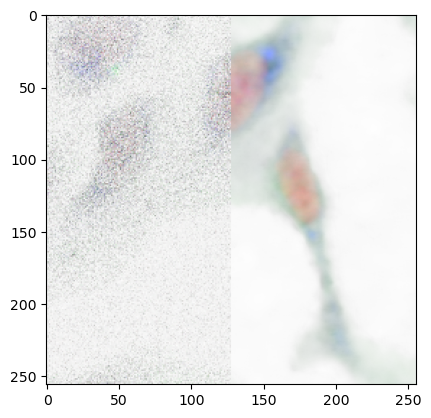

In [18]:
# create a cover image
im_idx = 9
cv_image_noisy = train_image[im_idx]
cv_image_pred = prediction[im_idx].squeeze()

# create image
cover = np.zeros((4, 256, 256))
(_, height, width) = cv_image_noisy.shape
assert height > 256
assert width > 256

# get min and max and reshape them so that they can be broadcasted with the images
noise_min = np.array(np.min(cv_image_noisy, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_noisy.ndim - 1))
]
noise_max = np.array(np.max(cv_image_noisy, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_noisy.ndim - 1))
]
pred_min = np.array(np.min(cv_image_pred, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_pred.ndim - 1))
]
pred_max = np.array(np.max(cv_image_pred, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_pred.ndim - 1))
]

# normalize train and prediction per channel
norm_noise = (cv_image_noisy - noise_min) / (noise_max - noise_min)
norm_pred = (cv_image_pred - pred_min) / (pred_max - pred_min)

# fill in halves
cover[:, :, : 256 // 2] = norm_noise[
    :,
    height // 2 - 256 // 2 : height // 2 + 256 // 2,
    width // 2 - 256 // 2 : width // 2,
]
cover[:, :, 256 // 2 :] = norm_pred[
    :,
    height // 2 - 256 // 2 : height // 2 + 256 // 2,
    width // 2 : width // 2 + 256 // 2,
]

# move C axis at the end
cover = np.moveaxis(cover, 0, -1)

# plot the single image
plt.imshow(cover)

# save the image
plt.imsave("JUMP_N2V.jpeg", cover)

In [6]:
metrics_dict = calculate_metrics(gt_image, train_image, data_range=22.0)
print("PSNR:   ", metrics_dict['PSNR'])
print("SIPSNR: ", metrics_dict['SIPSNR'])
print("SSIM:   ", metrics_dict['SSIM'])
print("MS-SSIM:", metrics_dict['MS-SSIM'])

PSNR:    29.56148734274428
SIPSNR:  33.27129079695812
SSIM:    0.5135774623946265
MS-SSIM: 0.89372337
